# 📅 Day 08 of 100 — Matplotlib & Seaborn Basics

📂 **GitHub Repo:** [100-Days-of-Data-Science / Day 009](https://github.com/imshoaibaslam/100-Days-of-Data-Science/tree/main/Day-09-Datascience)

---

## 🗂️ Agenda
1. Introduction to Matplotlib — Line, Bar, and Histogram
2. Customizing Plots — Titles, Labels, Colors
3. Introduction to Seaborn — Countplot, Boxplot, Heatmap
4. Matplotlib vs Seaborn — When to Use What

---

## 🎯 Deliverables
- [ ] Plot a line chart, bar chart, and histogram using Matplotlib
- [ ] Add titles, axis labels, and custom colors to plots
- [ ] Plot a countplot, boxplot, and heatmap using Seaborn
- [ ] Interpret what each chart type reveals about the data

---

## 📚 Learning Topics

| # | Topic | Description |
|---|-------|-------------|
| 1 | `plt.plot()` | Line chart — trends over a sequence |
| 2 | `plt.bar()` | Bar chart — comparing categories |
| 3 | `plt.hist()` | Histogram — distribution of a numeric column |
| 4 | `sns.countplot()` | Count of each category — like value_counts() visualized |
| 5 | `sns.boxplot()` | Distribution + outliers per category |
| 6 | `sns.heatmap()` | Correlation between numeric columns |





## 🔧 Imports



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline in the notebook
%matplotlib inline

# Set default figure size
plt.rcParams['figure.figsize'] = (10, 5)

---

## Step 0 — Load the Dataset

In [2]:
# Load the cleaned Wine Reviews dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head(3)

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm


---

## Step 1 — Matplotlib Basics

### What is Matplotlib?

Matplotlib is the **foundation of data visualization in Python**.
Every other visualization library — including Seaborn — is built on top of it.

Think of Matplotlib like a blank canvas.
You have full control over every element — but you have to draw everything yourself.

Basic structure:
```python
plt.plot(x, y)     # draw the chart
plt.title('...')   # add title
plt.xlabel('...')  # label x axis
plt.ylabel('...')  # label y axis
plt.show()         # display
```

#### Line Chart — Wine Score Distribution by Index

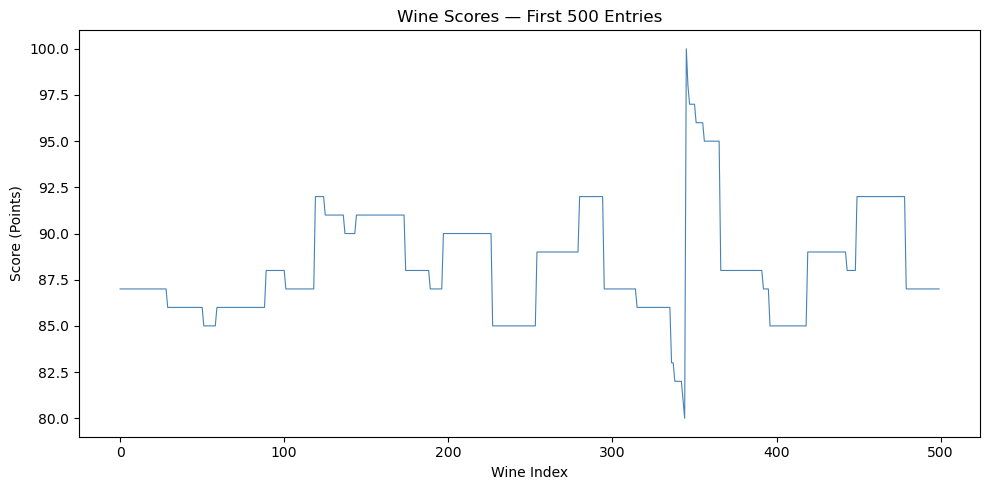

In [3]:
# Line chart — how scores are spread across the first 500 wines
plt.plot(df['points'][:500], color='steelblue', linewidth=0.8)

plt.title('Wine Scores — First 500 Entries')
plt.xlabel('Wine Index')
plt.ylabel('Score (Points)')
plt.tight_layout()
plt.show()

#### Bar Chart — Top 10 Countries by Review Count

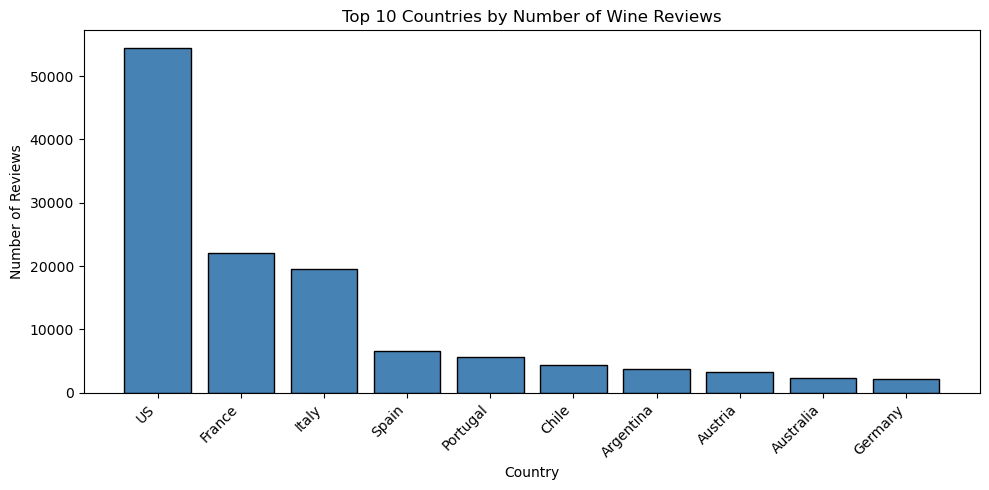

In [4]:
# Count reviews per country — take top 10
top_countries = df['country'].value_counts().head(10)

plt.bar(top_countries.index, top_countries.values, color='steelblue', edgecolor='black')

plt.title('Top 10 Countries by Number of Wine Reviews')
plt.xlabel('Country')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**What this tells us:**
- US dominates with the most reviews by a large margin
- France and Italy follow — the classic wine powerhouses
- A bar chart is the right tool whenever you are **comparing categories**

#### Histogram — Distribution of Wine Scores

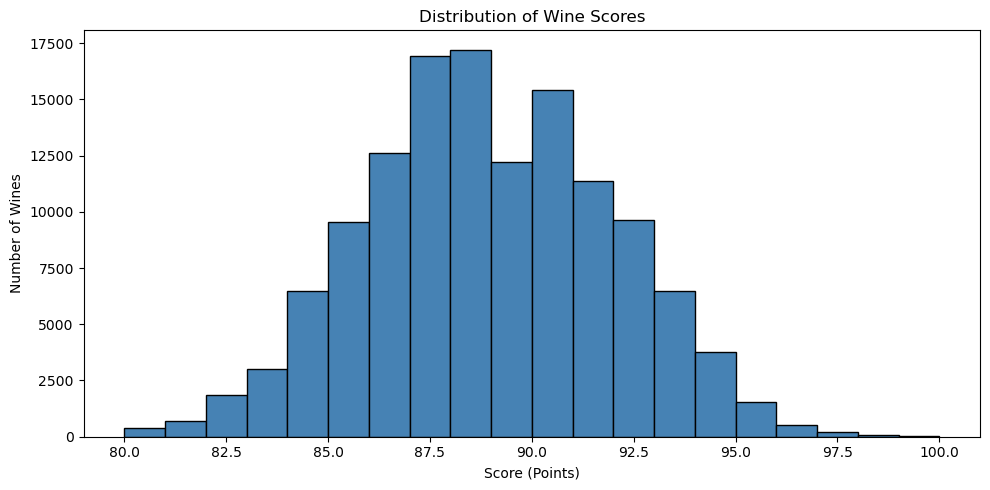

In [5]:
# Histogram — how are scores distributed across all 130,000 wines?
plt.hist(df['points'], bins=20, color='steelblue', edgecolor='black')

plt.title('Distribution of Wine Scores')
plt.xlabel('Score (Points)')
plt.ylabel('Number of Wines')
plt.tight_layout()
plt.show()

**What this tells us:**
- Scores cluster around 88 — the distribution is roughly normal
- Very few wines score below 82 or above 97
- A histogram is the right tool whenever you want to see **how a numeric column is distributed**

#### Bar vs Histogram — Key Difference

| | Bar Chart | Histogram |
|-|-----------|----------|
| Used for | Categorical data | Numeric data |
| X axis | Category labels | Value ranges (bins) |
| Question answered | How many per category? | How is this value distributed? |

---

## Step 2 — Seaborn Basics

### What is Seaborn?

Seaborn is built **on top of Matplotlib** and makes statistical visualization much easier.

Think of Seaborn like a higher-level tool:
- Less code for more polished charts
- Built-in statistical context — means, distributions, confidence intervals
- Works directly with DataFrames

**Matplotlib** → full control, more code
**Seaborn** → statistical charts, less code, more insight

#### Countplot — Reviews per Country (Top 10)

C:\Users\aslam\AppData\Local\Temp\ipykernel_9904\1495614150.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


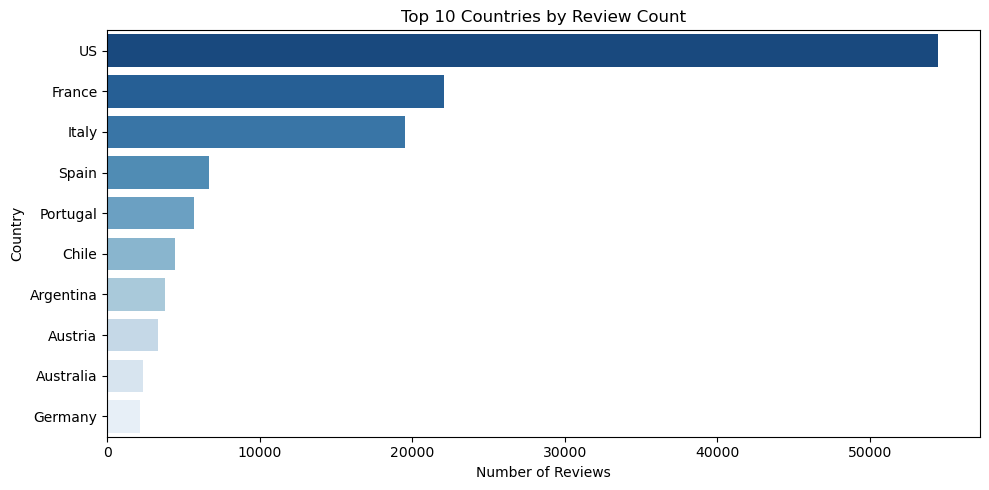

In [6]:
# Filter top 10 countries for a cleaner chart
top_10 = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_10)]

sns.countplot(
    data=df_top,
    y='country',
    order=top_10,
    palette='Blues_r'
)

plt.title('Top 10 Countries by Review Count')
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

#### Boxplot — Score Distribution per Top 5 Countries

A boxplot shows **distribution + spread + outliers** for each category — all in one chart.

```
What each part means:
─────────────────────
Box         → middle 50% of scores (IQR)
Line inside → median score
Whiskers    → min and max within range
Dots        → outliers
```

C:\Users\aslam\AppData\Local\Temp\ipykernel_9904\3040286019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


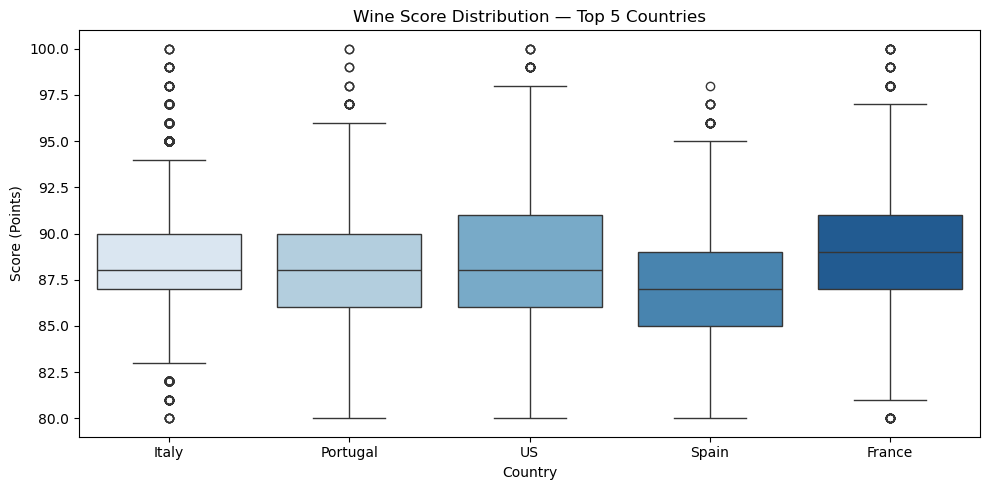

In [7]:
# Score distribution per top 5 countries
top_5 = df['country'].value_counts().head(5).index
df_top5 = df[df['country'].isin(top_5)]

sns.boxplot(
    data=df_top5,
    x='country',
    y='points',
    palette='Blues'
)

plt.title('Wine Score Distribution — Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Score (Points)')
plt.tight_layout()
plt.show()

**What this tells us:**
- All top countries have similar median scores — around 88
- France and Italy show slightly higher medians
- Outlier dots above the whiskers = exceptional wines in every country
- A boxplot reveals what a bar chart hides — **the spread of the data**

#### Heatmap — Correlation Between Numeric Columns

A heatmap shows **how strongly numeric columns are related** to each other.

```
Correlation value:
+1.0  → perfect positive relationship
 0.0  → no relationship
-1.0  → perfect negative relationship
```

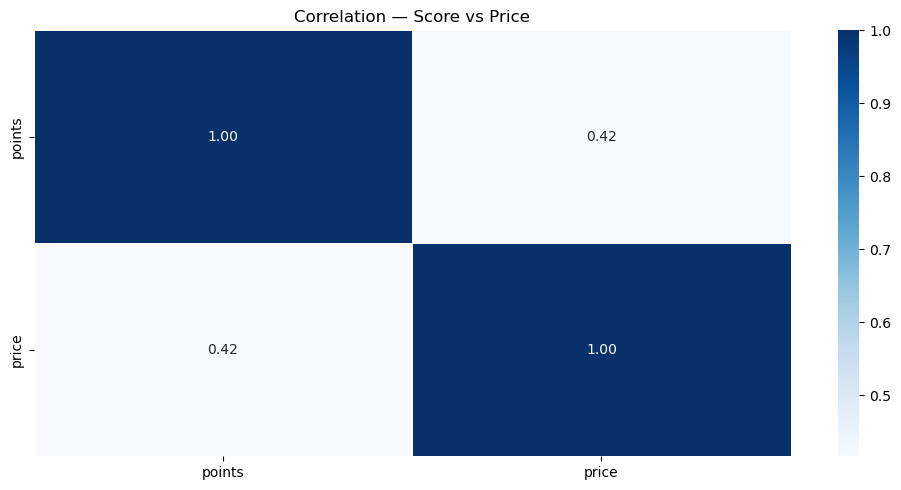

In [8]:
# Correlation matrix of numeric columns only
numeric_df = df[['points', 'price']].dropna()

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation — Score vs Price')
plt.tight_layout()
plt.show()

**What this tells us:**
- `points` and `price` have a moderate positive correlation (~0.42)
- Higher priced wines tend to score higher — but it is not a strong rule
- Price alone does not guarantee quality — the data proves it

---

## 💡 When to Use What

| Chart | Use When |
|-------|----------|
| Line chart | Showing trends over time or sequence |
| Bar chart | Comparing values across categories |
| Histogram | Showing distribution of a numeric column |
| Countplot | Visualizing frequency of categories |
| Boxplot | Comparing distribution + spread across groups |
| Heatmap | Showing correlation between numeric columns |

---

## 🌍 Real World Usage

**Matplotlib** is used in production reporting pipelines, scientific publications, and custom dashboards where pixel-level control is needed.

**Seaborn** is used in exploratory data analysis, statistical reporting, and anywhere you need clean, publication-ready charts with minimal code.

In real data science projects, both are used together — Matplotlib for structure and control, Seaborn for statistical insight and speed.

---

## 🔑 Key Takeaways

- Matplotlib is the foundation — Seaborn is built on top of it
- Always label your axes and add a title — unlabelled charts are meaningless
- Histogram ≠ Bar chart — one is for numeric distribution, one is for categories
- Boxplot reveals what a bar chart hides — the spread and outliers
- Heatmap shows correlation — does not prove causation
- `%matplotlib inline` ensures charts display inside the notebook

---

## 🏁 Conclusion

Today we moved from numbers to visuals — using Matplotlib and Seaborn to turn 130,000 rows of wine data into charts that reveal patterns instantly.

Visualization is not decoration. It is how you communicate findings, spot outliers, understand distributions, and build intuition about your data before modelling. From Day 11 onwards, we use these tools in every analysis.

---

## 📝 Personal Notes & Observations

> Write anything you learned, got confused about, or want to remember here.

---

## ✅ Day 08 Complete — 92 days to go!

<p align="center">
  <a href="https://github.com/imshoaibaslam/100-Days-of-Data-Science/tree/main/Day-09-Datascience">📂 View Full Code on GitHub</a>
</p>